# Machine Learning Model Training

## Objective

The objective of this notebook is to train and evaluate machine learning models capable of classifying driving behavior using vehicle motion sensor data.

Two datasets are evaluated:

1. Raw Sensor Data
2. Engineered Statistical Features

Two machine learning algorithms are compared:

- Logistic Regression
- Random Forest

The objective is to determine whether engineered features improve prediction performance compared to raw sensor readings.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import joblib

In [2]:
raw_df = pd.read_csv("../data/sensor_raw.csv")

features_df = pd.read_csv("../data/features_14.csv")

In [3]:
X_raw = raw_df.drop(columns="Target(Class)")

y_raw = raw_df["Target(Class)"]

## Train Test Split (Raw)

In [4]:
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw,
    y_raw,
    test_size=0.2,
    random_state=42,
    stratify=y_raw
)

## Standardization

In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_raw)

X_test_scaled = scaler.transform(X_test_raw)

## Logistic Regression

In [6]:
lr_raw = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_raw.fit(
    X_train_scaled,
    y_train_raw
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

Prediction

In [7]:
y_pred_lr = lr_raw.predict(X_test_scaled)

Accuracy

In [8]:
lr_accuracy = accuracy_score(
    y_test_raw,
    y_pred_lr
)

print(f"Accuracy : {lr_accuracy:.4f}")

Accuracy : 0.4350


Classification Report

In [9]:
print(classification_report(
    y_test_raw,
    y_pred_lr
))

              precision    recall  f1-score   support

           1       0.36      0.32      0.34        50
           2       0.55      0.38      0.45        58
           3       0.43      0.69      0.53        70
           4       0.41      0.24      0.31        45

    accuracy                           0.43       223
   macro avg       0.44      0.41      0.41       223
weighted avg       0.44      0.43      0.42       223



Confusion Matrix

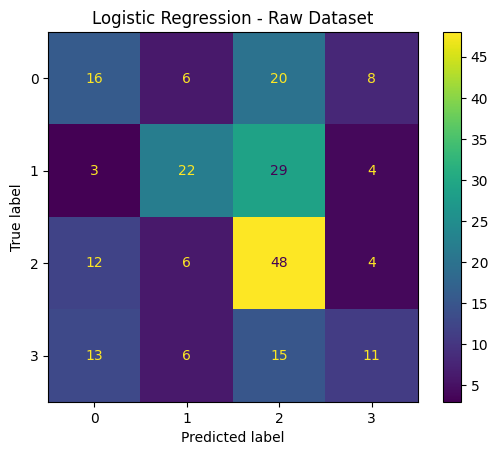

In [10]:
cm = confusion_matrix(
    y_test_raw,
    y_pred_lr
)

ConfusionMatrixDisplay(cm).plot()

plt.title("Logistic Regression - Raw Dataset")

plt.savefig(
    "../reports/figures/lr_raw_cm.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Random Forest

In [11]:
rf_raw = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_raw.fit(
    X_train_raw,
    y_train_raw
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

Prediction

In [12]:
y_pred_rf = rf_raw.predict(
    X_test_raw
)

Accuracy

In [13]:
rf_accuracy = accuracy_score(
    y_test_raw,
    y_pred_rf
)

print(rf_accuracy)

0.6816143497757847


Classification Report

In [14]:
print(classification_report(
    y_test_raw,
    y_pred_rf
))

              precision    recall  f1-score   support

           1       0.67      0.52      0.58        50
           2       0.69      0.64      0.66        58
           3       0.62      0.79      0.69        70
           4       0.83      0.76      0.79        45

    accuracy                           0.68       223
   macro avg       0.70      0.67      0.68       223
weighted avg       0.69      0.68      0.68       223



Confusion Matrix

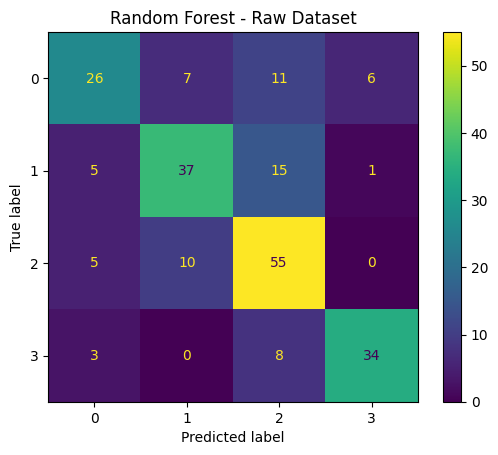

In [15]:
cm = confusion_matrix(
    y_test_raw,
    y_pred_rf
)

ConfusionMatrixDisplay(cm).plot()

plt.title("Random Forest - Raw Dataset")

plt.savefig(
    "../reports/figures/rf_raw_cm.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

Random Forest achieves higher classification accuracy than Logistic Regression on the raw sensor dataset, indicating that the relationship between motion sensor readings and driving behavior is likely non-linear.

## Engineered Dataset


In [16]:
X_feat = features_df.drop(columns="Target")

y_feat = features_df["Target"]

#### Chronological Split

In [17]:
train_parts = []
test_parts = []

for cls in sorted(features_df["Target"].unique()):

    group = features_df[
        features_df["Target"] == cls
    ]

    split_index = int(len(group) * 0.8)

    train_parts.append(group.iloc[:split_index])

    test_parts.append(group.iloc[split_index:])

train_df = pd.concat(train_parts)

test_df = pd.concat(test_parts)

In [18]:
X_train_feat = train_df.drop(columns="Target")
y_train_feat = train_df["Target"]

X_test_feat = test_df.drop(columns="Target")
y_test_feat = test_df["Target"]

In [19]:
scaler_feat = StandardScaler()

X_train_feat_scaled = scaler_feat.fit_transform(
    X_train_feat
)

X_test_feat_scaled = scaler_feat.transform(
    X_test_feat
)

## Logistic Regression

In [20]:
lr_feat = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_feat.fit(
    X_train_feat_scaled,
    y_train_feat
)

pred_lr_feat = lr_feat.predict(
    X_test_feat_scaled
)

lr_feat_accuracy = accuracy_score(
    y_test_feat,
    pred_lr_feat
)

print(lr_feat_accuracy)

0.6891891891891891


Classification Report

In [21]:
print(classification_report(
    y_test_feat,
    pred_lr_feat
))

              precision    recall  f1-score   support

           1       0.42      0.84      0.56        50
           2       0.90      0.93      0.91        57
           3       0.93      0.19      0.31        70
           4       0.90      1.00      0.95        45

    accuracy                           0.69       222
   macro avg       0.79      0.74      0.68       222
weighted avg       0.80      0.69      0.65       222



Confusion Matrix

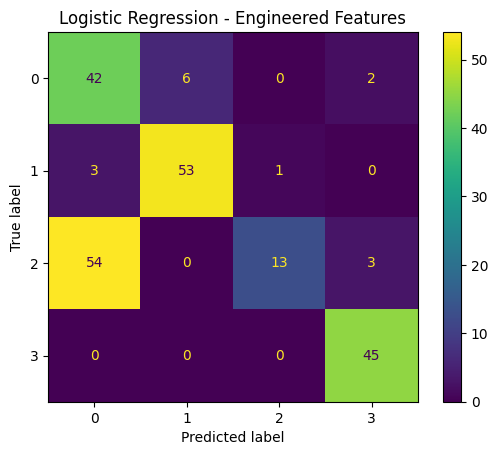

In [22]:
cm = confusion_matrix(
    y_test_feat,
    pred_lr_feat
)

ConfusionMatrixDisplay(cm).plot()

plt.title("Logistic Regression - Engineered Features")

plt.savefig(
    "../reports/figures/lr_feature_cm.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Random Forest

In [23]:
rf_feat = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_feat.fit(
    X_train_feat,
    y_train_feat
)

pred_rf_feat = rf_feat.predict(
    X_test_feat
)

rf_feat_accuracy = accuracy_score(
    y_test_feat,
    pred_rf_feat
)

print(rf_feat_accuracy)

0.7207207207207207


Classification Report

In [24]:
print(classification_report(
    y_test_feat,
    pred_rf_feat
))

              precision    recall  f1-score   support

           1       0.44      0.88      0.59        50
           2       1.00      1.00      1.00        57
           3       1.00      0.20      0.33        70
           4       0.88      1.00      0.94        45

    accuracy                           0.72       222
   macro avg       0.83      0.77      0.71       222
weighted avg       0.85      0.72      0.68       222



Confusion Matrix

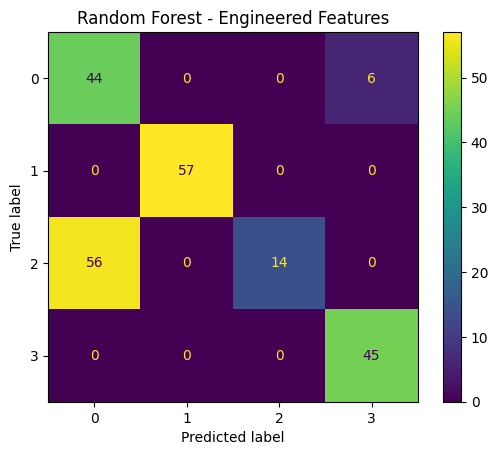

In [25]:
cm = confusion_matrix(
    y_test_feat,
    pred_rf_feat
)

ConfusionMatrixDisplay(cm).plot()

plt.title("Random Forest - Engineered Features")

plt.savefig(
    "../reports/figures/rf_feature_cm.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Feature Importance

In [26]:
importance = pd.DataFrame({
    "Feature": X_train_feat.columns,
    "Importance": rf_feat.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

Top 10

In [27]:
importance.head(10)

,Feature,Importance
32,GyroMeanZ,0.083772
19,AccMaxY,0.074946
47,GyroMinZ,0.068717
59,GyroStdZ,0.067952
41,GyroSumZ,0.066758
50,GyroMaxZ,0.059259
53,GyroVarZ,0.044144
35,GyroCovZ,0.043007
18,AccMaxX,0.038150
1,AccMeanY,0.037940


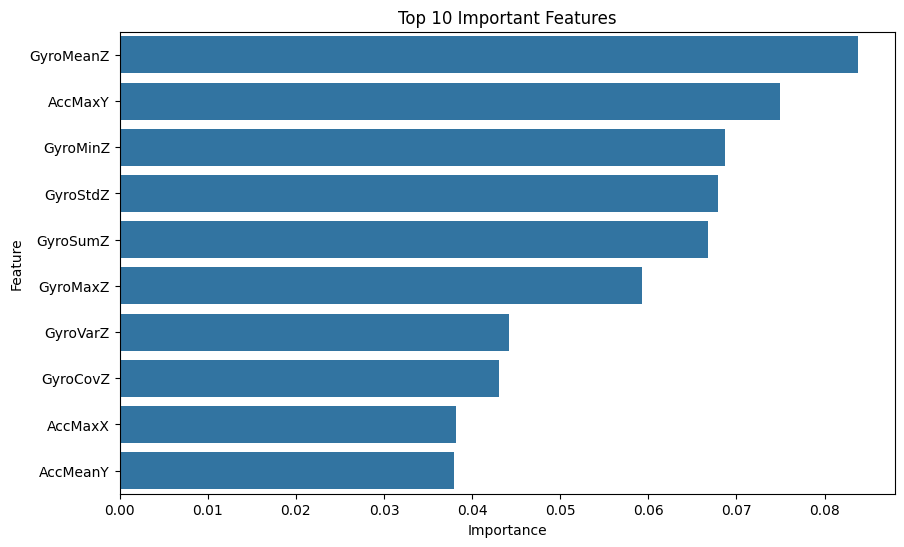

In [28]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.savefig(
    "../reports/figures/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [29]:
joblib.dump(
    rf_feat,
    "../models/random_forest.pkl"
)

print("Model Saved Successfully!")

Model Saved Successfully!


### Final Comparison Table

In [30]:
comparison = pd.DataFrame({
    "Dataset":[
        "Raw",
        "Raw",
        "Engineered",
        "Engineered"
    ],

    "Model":[
        "Logistic Regression",
        "Random Forest",
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy":[
        lr_accuracy,
        rf_accuracy,
        lr_feat_accuracy,
        rf_feat_accuracy
    ]
})

comparison

,Dataset,Model,Accuracy
0,Raw,Logistic Regression,0.434978
1,Raw,Random Forest,0.681614
2,Engineered,Logistic Regression,0.689189
3,Engineered,Random Forest,0.720721


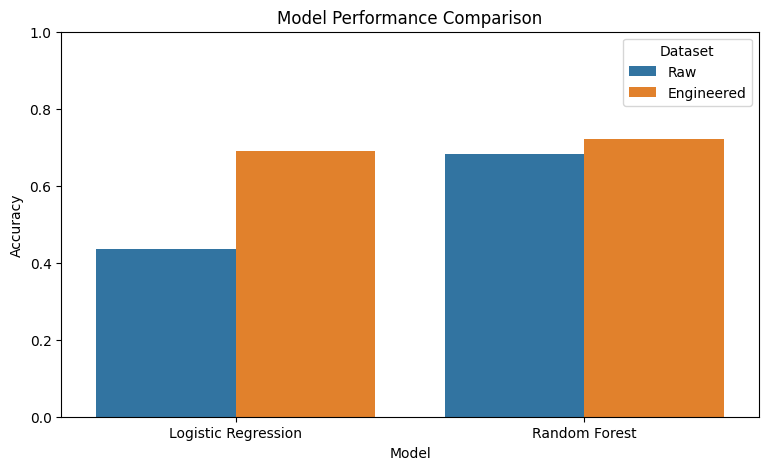

In [31]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy",
    hue="Dataset"
)

plt.title("Model Performance Comparison")

plt.ylim(0,1)

plt.savefig(
    "../reports/figures/model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Machine Learning Summary

The machine learning experiments demonstrate that:

- Logistic Regression provides a useful baseline but struggles to capture complex relationships in the sensor data.
- Random Forest consistently outperforms Logistic Regression by modeling non-linear interactions.
- Engineered statistical features significantly improve classification performance compared to raw sensor readings.
- Feature importance analysis highlights gyroscope-based statistics as the strongest predictors of driving behavior.

These results support the project's objective that summarizing sensor readings over time provides richer information for driver behavior classification than using instantaneous sensor measurements alone.